In [6]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt



In [7]:
np.random.seed(0)

# Demand PMF mô phỏng 3
d_mu_target = 1378
d_std_target = 285

x = np.arange(0, 3000)
pmf = norm.pdf(x, d_mu_target, d_std_target)
pmf = pmf / pmf.sum()

def attributes(pmf, x):
    mu = np.sum(pmf * x)
    std = np.sqrt(np.sum(x**2 * pmf) - mu**2)
    return mu, std

d_mu, d_std = attributes(pmf, x)

# Lead time PMF 
L_x = np.array([3, 4, 5])
L_pmf = np.array([0.1, 0.7, 0.2])

L_mu, L_std = attributes(L_pmf, L_x)
L_median = 4
L_max = 5

# Cost parameters
k = 1000
h = 1.25
b = 25
time = 20000
R = 1

# Tạo demand path
d = np.random.choice(x, size=time, p=pmf).astype(int)



In [8]:
def simulation(R, Ss):
    S = int(round(d_mu * (R + L_mu) + round(Ss)))

    hand = np.zeros(time, dtype=int)
    transit = np.zeros((time, L_max + 1), dtype=int)
    unit_shorts = np.zeros(time, dtype=int)
    stockout_period = np.full(time, False, dtype=bool)
    stockout_cycle = []

    hand[0] = S - d[0]
    transit[1, L_median] = d[0]

    p = np.zeros(time)
    p[0] = S - d[0] / 2

    c_k = k
    c_h = h * p[0]
    c_b = 0

    for t in range(1, time):
        if transit[t-1, 0] > 0:
            stockout_cycle.append(stockout_period[t-1])

        available_start = hand[t-1] + transit[t-1, 0]
        unit_shorts[t] = max(0, d[t] - max(0, available_start))

        hand[t] = hand[t-1] - d[t] + transit[t-1, 0]
        stockout_period[t] = hand[t] < 0

        transit[t, :-1] = transit[t-1, 1:]

        if t % R == 0:
            actual_L = int(np.random.choice(L_x, 1, p=L_pmf)[0])
            net = hand[t] + transit[t].sum()
            transit[t, actual_L] += S - net
            c_k += k

        if hand[t] > 0:
            p[t] = (hand[t-1] + transit[t-1, 0] + hand[t]) / 2
        else:
            p[t] = max(hand[t-1] + transit[t-1, 0], 0)**2 / max(d[t], 1) / 2

        c_h += h * p[t]
        c_b += b * max(0, -hand[t])

    SL_alpha = 1 - sum(stockout_cycle) / len(stockout_cycle)
    fill_rate = 1 - unit_shorts.sum() / d.sum()
    cost = (c_h + c_b + c_k) / time

    return cost, SL_alpha, fill_rate, Ss



In [9]:
def find_best_Ss(step_size=1, start=0, threshold=1.1, max_iter=1000):
    results = []

    Ss_opt = start
    results.append(simulation(R, Ss_opt))
    cost_opt = results[-1][0]

    Ss_new = start + step_size
    results.append(simulation(R, Ss_new))
    cost_new = results[-1][0]

    it = 0
    while cost_new < cost_opt * threshold and it < max_iter:
        if cost_new < cost_opt:
            cost_opt = cost_new
            Ss_opt = Ss_new

        Ss_new += step_size

        if Ss_new < 0:
            break

        results.append(simulation(R, Ss_new))
        cost_new = results[-1][0]
        it += 1

    return results



Demand mean: 1378.0
Demand std: 285.0
Lead time mean: 4.1
Lead time std: 0.54
Starting safety stock: 1661
Step size: 14

Best result:
Cost                   4473.090224
Cycle Service Level       0.920010
Fill Rate                 0.979831
Safety Stock           1507.000000
Name: 61, dtype: float64


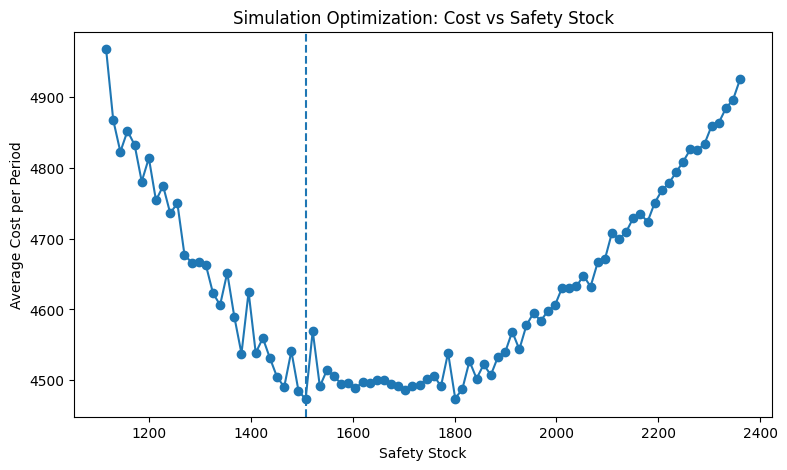

In [10]:
# Smart-start heuristic
alpha_opt = 1 - h * R / (b * 1.1)

x_std = np.sqrt((L_mu + R) * d_std**2 + L_std**2 * d_mu**2)
Ss_start = int(round(x_std * norm.ppf(alpha_opt)))

step_size = int(max(1, round(d_mu / 100)))

# Chạy theo hai hướng: tăng và giảm safety stock
np.random.seed(123)
results_increase = find_best_Ss(step_size=step_size, start=Ss_start)

np.random.seed(123)
results_decrease = find_best_Ss(step_size=-step_size, start=Ss_start-step_size)

results = results_increase + results_decrease

df_results = pd.DataFrame(
    results,
    columns=['Cost', 'Cycle Service Level', 'Fill Rate', 'Safety Stock']
)

df_results = df_results.sort_values('Safety Stock').drop_duplicates('Safety Stock')

best = df_results.loc[df_results['Cost'].idxmin()]

print("Demand mean:", round(d_mu, 2))
print("Demand std:", round(d_std, 2))
print("Lead time mean:", round(L_mu, 2))
print("Lead time std:", round(L_std, 2))
print("Starting safety stock:", Ss_start)
print("Step size:", step_size)

print("\nBest result:")
print(best)

# Vẽ biểu đồ
plt.figure(figsize=(9,5))
plt.plot(df_results['Safety Stock'], df_results['Cost'], marker='o')
plt.axvline(best['Safety Stock'], linestyle='--')
plt.title('Simulation Optimization: Cost vs Safety Stock')
plt.xlabel('Safety Stock')
plt.ylabel('Average Cost per Period')
plt.show()